In [87]:
import xgboost as xgb
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path

import xesmf as xe

from sklearn.preprocessing import StandardScaler

import sys

sys.path.append('/home/548/cd3022/repos/solar-nowcast/modules')
import sat_preprocess

In [2]:
model = xgb.XGBRegressor()
# model.load_model("/scratch/er8/cd3022/xgb_models/test_model.json")
model.load_model("/scratch/er8/cd3022/xgb_models/radiance_model.json")

In [46]:
data = pd.read_parquet('/scratch/er8/cd3022/xgb_datasets/syd_radiances_2024-01-01.parquet')

In [56]:
X = data.drop(columns=['surface_global_irradiance'])
for n in range(1, 11):
    X = X.drop(columns=[f'surface_global_irradiance_t{n}'])
y = data['surface_global_irradiance_t3']

In [75]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [58]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [92]:
df = data[['surface_global_irradiance', 'surface_global_irradiance_t3']].iloc[split_index:]
df['forecast'] = model.predict(X_test_scaled)

In [93]:
ds = df.to_xarray()

Text(0, 0.5, 'XGB Forecast T+30min')

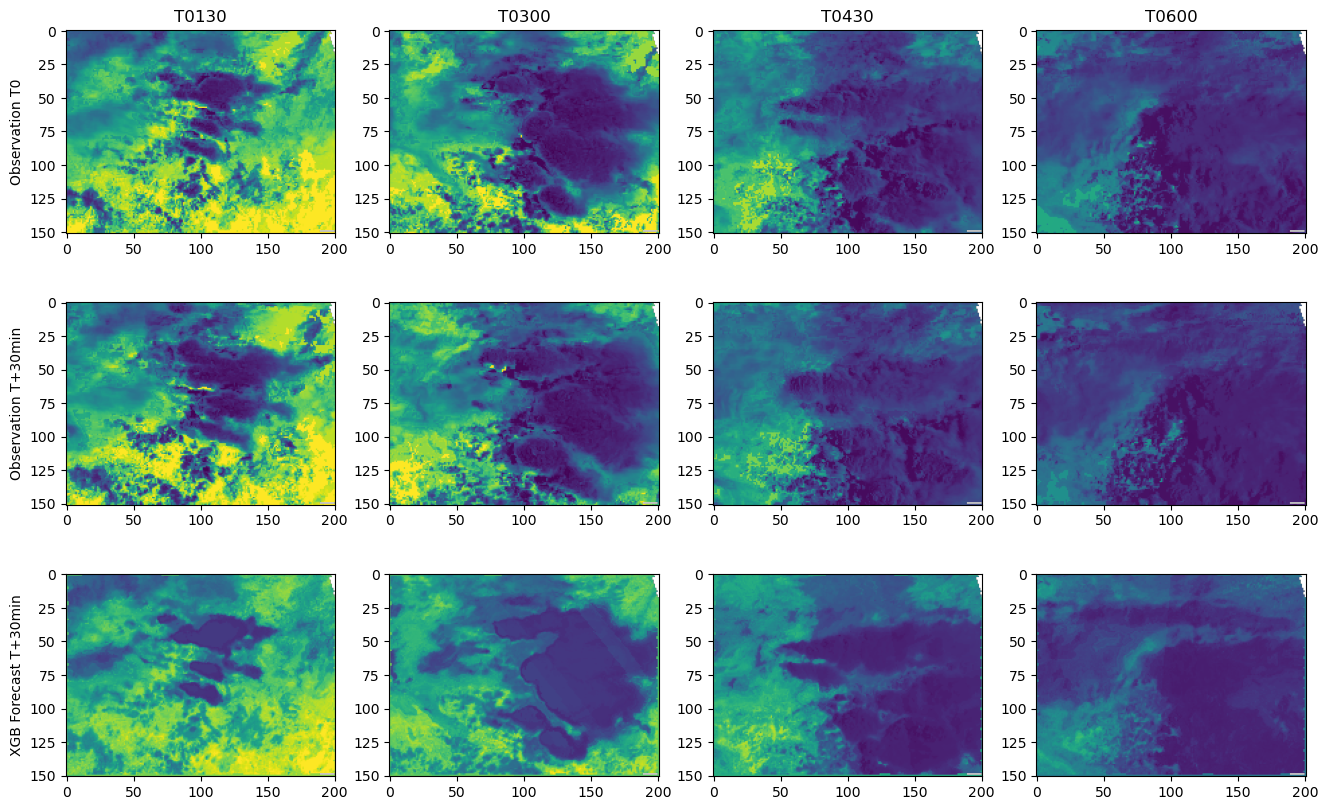

In [102]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(16,10))

times = [
    'T0130',
    'T0300',
    'T0430',
    'T0600'
]

for i, t in enumerate(times):
    ds_t = ds.sel(time=f'2024-01-04{t}')
    ax[0,i].imshow(
        ds_t.surface_global_irradiance,
        vmin=0, vmax=1000
    )
    ax[1,i].imshow(
        ds_t.surface_global_irradiance_t3,
        vmin=0, vmax=1000
    )
    ax[2,i].imshow(
        ds_t.forecast,
        vmin=0, vmax=1000
    )

    ax[0,i].set_title(t)
ax[0,0].set_ylabel('Observation T0')
ax[1,0].set_ylabel('Observation T+30min')
ax[2,0].set_ylabel('XGB Forecast T+30min')

In [105]:
gso_path = Path('/scratch/er8/mm4602/gso/output/nwc_20240701_20251231/2025/01/01')
gso_files = [f for f in gso_path.glob('*.nc')]

gso = xr.open_mfdataset(gso_files)

ValueError: Resulting object does not have monotonic global indexes along dimension time

In [106]:
gso = xr.open_dataset(files[0])

In [107]:
gso

<xarray.Dataset> Size: 260MB
Dimensions:                     (time: 1, latitude: 1726, longitude: 2214)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2024-01-05T21:00:00
  * latitude                    (latitude) float32 7kB -44.5 -44.48 ... -10.0
  * longitude                   (longitude) float32 9kB 112.0 112.0 ... 156.3
Data variables:
    crs                         int32 4B ...
    surface_global_irradiance   (time, latitude, longitude) float64 31MB ...
    direct_normal_irradiance    (time, latitude, longitude) float64 31MB ...
    surface_diffuse_irradiance  (time, latitude, longitude) float64 31MB ...
    quality_mask                (time, latitude, longitude) float64 31MB ...
    cloud_type                  (time, latitude, longitude) float32 15MB ...
    cloud_optical_depth         (time, latitude, longitude) float64 31MB ...
    solar_elevation             (time, latitude, longitude) float64 31MB ...
    solar_azimuth               (time, latitude, longitude) float64 31MB ...
    julian_date                 (time, latitude, longitude) float64 31MB ...
Attributes: (12/57)
    Conventions:                      CF-1.7
    Metadata_Conventions:             Unidata Dataset Discovery v1.0
    acknowledgment:                   The following acknowledgement is requir...
    cdm_data_type:                    grid
    comment:                          Solar radiation data derived from satel...
    contributor_name:                 Mines ParisTech; Commonwealth of Austra...
    ...                               ...
    date_created:                     20240408T051345Z
    bias_correction_applied:          1
    bias_correction_applied_meaning:  0: not applied; 1:applied
    quality:                          0
    quality_meaning:                  0: no_known_issues 1: known_issue 
    history:                          heliosat-4; post_process_p1s.py